# Modelo conducto + cámara magmática acoplados

Extensión del modelo transiente que incluye la **deflación de la cámara** durante la erupción.

## Física agregada

La presión de cámara $P_i(t)$ ya no es constante:

$$\frac{dP_i}{dt} = -\frac{K_{\rm eff}}{V_{\rm cam}} \cdot Q_{\rm vol}(t) + \dot{P}_{\rm recarga}$$

donde $Q_{\rm vol} = q\cdot A/\rho_m$ es el flujo volumétrico eruptivo.

A medida que la cámara se deflaciona, la erupción se debilita y puede apagarse.
Si hay recarga ($\dot{P}_{\rm recarga} > 0$), el ciclo puede repetirse → **múltiples pulsos**.

## Experimentos
1. **Sin recarga** — un único pulso explosivo que se agota.
2. **Con recarga** — múltiples pulsos, análogo a las 3 fases del Calbuco 2015.
3. **Comparación** de ambos escenarios en el mismo gráfico.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextlib, os, sys

sys.path.insert(0, os.getcwd())

from calbuco2015d       import *
from RIconduitex5_5     import RIconduitex5_5_f
from RIconduit1D_chamber import RIconduit1D_chamber_f

# Parámetros Calbuco (renombrar para evitar colisión)
radius1 = radius1
overP1  = overP1
h2o1    = h2o1
T1      = T1
xi1     = xi1

print('Parámetros Calbuco 2015:')
print(f'  radio         = {radius1} m')
print(f'  sobrepresion  = {overP1/1e6:.1f} MPa')
print(f'  H2O           = {h2o1} wt%')
print(f'  T             = {T1-273.15:.0f} C')
print(f'  xi            = {xi1}')

Parámetros Calbuco 2015:
  radio         = 16 m
  sobrepresion  = 5.0 MPa
  H2O           = 4 wt%
  T             = 970 C
  xi            = 0.25


## 1. Obtener phi_crit del modelo estacionario

In [2]:
with open(os.devnull, 'w') as f:
    with contextlib.redirect_stdout(f):
        result_stat = RIconduitex5_5_f(radius1, overP1, h2o1, T1, xi1)

phicrit_calc = result_stat[9]
print(f'phi_crit (formula Ca) = {phicrit_calc:.4f}')

phi_crit (formula Ca) = 0.5795


## 2. Experimento A — sin recarga (un solo pulso)

In [3]:
outA = RIconduit1D_chamber_f(
    radius           = radius1,
    Pressure         = overP1,
    wt               = h2o1,
    Temperature      = T1,
    content_crystal  = xi1,
    phicrit_override = phicrit_calc,
    # ── cámara ──────────────────────────────────────────────
    V_cam            = 2e9,    # 2 km³
    K_eff            = 1e9,    # 1 GPa
    recharge_rate    = 0.0,    # sin recarga → un solo pulso
    # ── conducto ────────────────────────────────────────────
    tau_relax        = 1.0,
    N_z              = 100,
    T_max            = 600.0, # ~33 min
    save_every       = 40,
    CFL              = 0.4,
)

══════════════════════════════════════════════════════════════════
  RIconduit1D_chamber — Conducto + Cámara acoplados
  Pi(t=0)  = 1.835e+08 Pa   ΔP_0 = 5.0 MPa   ρm = 2463 kg/m³
  V_cam    = 2.00e+09 m³  (2.00 km³)
  K_eff    = 1.00e+09 Pa
  recarga  = 0.0 Pa/s
  τ_depl   ≈ 2574 s  (escala de deflación inicial)
  q(t=0)   = 11899.2 kg/m²/s   Q(t=0) = 9569937 kg/s
  N_z=100  Δz=70.7 m   T_max=600 s   CFL=0.4
  φ_crit   = 0.58   CI: phi=0 (pre-erupcion)
  P_vent(t=0) = 1.01 bar
══════════════════════════════════════════════════════════════════
  t=    9.1 s  ΔP=+4.95 MPa  Q=68022829 kg/s  z_frag=-1.34 km  φ_max=0.947  P_vent=6.38 bar  nfrag=20          Δt=0.078 s
  t=   12.2 s  ΔP=+4.91 MPa  Q=78300789 kg/s  z_frag=-1.56 km  φ_max=0.946  P_vent=2.24 bar  nfrag=23          Δt=0.079 s
  t=   15.3 s  ΔP=+4.86 MPa  Q=79450848 kg/s  z_frag=-1.56 km  φ_max=0.942  P_vent=1.01 bar  nfrag=23          Δt=0.078 s
  t=   18.5 s  ΔP=+4.81 MPa  Q=79408987 kg/s  z_frag=-1.56 km  φ_max=0.942  P_vent=1

## 3. Experimento B — con recarga (múltiples pulsos)

La tasa de recarga es ~5 MPa / 2 h ≈ 700 Pa/s (escala típica para Calbuco 2015).

In [4]:
outB = RIconduit1D_chamber_f(
    radius           = radius1,
    Pressure         = overP1,
    wt               = h2o1,
    Temperature      = T1,
    content_crystal  = xi1,
    phicrit_override = phicrit_calc,
    # ── cámara ──────────────────────────────────────────────
    V_cam            = 2e9,    # 2 km³
    K_eff            = 1e9,    # 1 GPa
    recharge_rate    = 3000.0,  # Pa/s → ~2 h para recuperar 5 MPa
    # ── conducto ────────────────────────────────────────────
    tau_relax        = 1.0,
    N_z              = 100,
    T_max            = 2500.0, # ~100 min: tiempo para ver 2-3 pulsos
    save_every       = 80,
    CFL              = 0.4,
)

══════════════════════════════════════════════════════════════════
  RIconduit1D_chamber — Conducto + Cámara acoplados
  Pi(t=0)  = 1.835e+08 Pa   ΔP_0 = 5.0 MPa   ρm = 2463 kg/m³
  V_cam    = 2.00e+09 m³  (2.00 km³)
  K_eff    = 1.00e+09 Pa
  recarga  = 3000.0 Pa/s
  τ_depl   ≈ 2574 s  (escala de deflación inicial)
  q(t=0)   = 11899.2 kg/m²/s   Q(t=0) = 9569937 kg/s
  N_z=100  Δz=70.7 m   T_max=2500 s   CFL=0.4
  φ_crit   = 0.58   CI: phi=0 (pre-erupcion)
  P_vent(t=0) = 1.01 bar
══════════════════════════════════════════════════════════════════
  t=   12.2 s  ΔP=+4.94 MPa  Q=78376480 kg/s  z_frag=-1.56 km  φ_max=0.947  P_vent=2.16 bar  nfrag=23          Δt=0.079 s
  t=   18.5 s  ΔP=+4.86 MPa  Q=79485749 kg/s  z_frag=-1.56 km  φ_max=0.942  P_vent=1.01 bar  nfrag=23          Δt=0.078 s
  t=   24.8 s  ΔP=+4.78 MPa  Q=79290500 kg/s  z_frag=-1.56 km  φ_max=0.942  P_vent=1.07 bar  nfrag=23          Δt=0.078 s
  t=   31.0 s  ΔP=+4.70 MPa  Q=79144378 kg/s  z_frag=-1.56 km  φ_max=0.942  P_ve

## 4. Pulso eruptivo — flujo másico Q(t) y presión de cámara Pi(t)

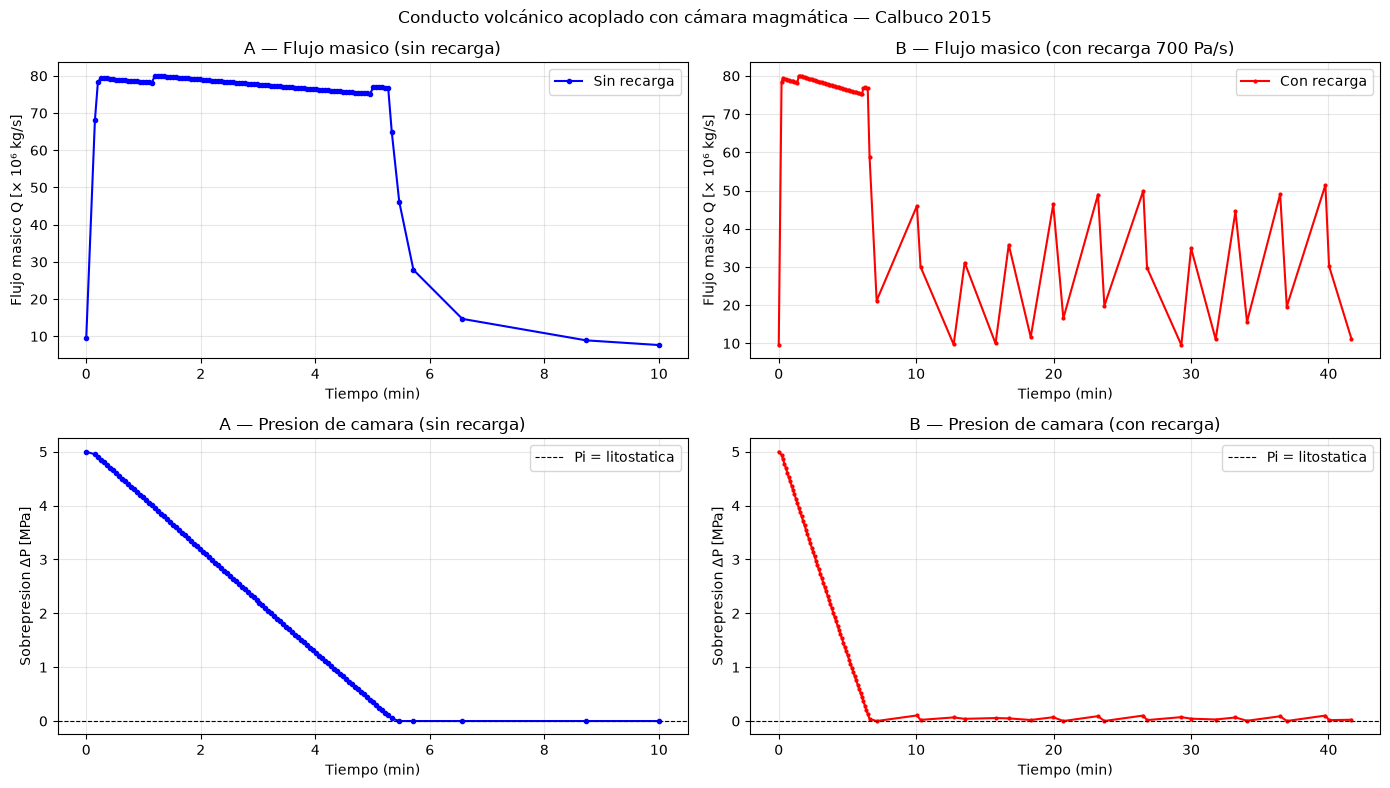

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Conducto volcánico acoplado con cámara magmática — Calbuco 2015', fontsize=12)

P_lith = outA['P_lith']

# ── Exp A: Q(t) ─────────────────────────────────────────────────────────────
ax = axes[0, 0]
tA = outA['t_save']
QA = outA['q_hist'] * outA['A_conduit']
ax.plot(tA/60, QA/1e6, 'b-o', ms=3, label='Sin recarga')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('Flujo masico Q [× 10⁶ kg/s]')
ax.set_title('A — Flujo masico (sin recarga)')
ax.grid(True, alpha=0.3)
ax.legend()

# ── Exp A: Pi(t) ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
dPA = (np.array(outA['Pi_hist']) - P_lith) / 1e6
ax.plot(tA/60, dPA, 'b-o', ms=3)
ax.axhline(0, color='k', ls='--', lw=0.8, label='Pi = litostatica')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('Sobrepresion ΔP [MPa]')
ax.set_title('A — Presion de camara (sin recarga)')
ax.grid(True, alpha=0.3)
ax.legend()

# ── Exp B: Q(t) ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
tB = outB['t_save']
QB = outB['q_hist'] * outB['A_conduit']
ax.plot(tB/60, QB/1e6, 'r-o', ms=2, label='Con recarga')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('Flujo masico Q [× 10⁶ kg/s]')
ax.set_title('B — Flujo masico (con recarga 700 Pa/s)')
ax.grid(True, alpha=0.3)
ax.legend()

# ── Exp B: Pi(t) ─────────────────────────────────────────────────────────────
ax = axes[1, 1]
dPB = (np.array(outB['Pi_hist']) - P_lith) / 1e6
ax.plot(tB/60, dPB, 'r-o', ms=2)
ax.axhline(0, color='k', ls='--', lw=0.8, label='Pi = litostatica')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('Sobrepresion ΔP [MPa]')
ax.set_title('B — Presion de camara (con recarga)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('pulso_eruptivo_camara.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evolución del perfil φ(z) — Exp A (sin recarga)

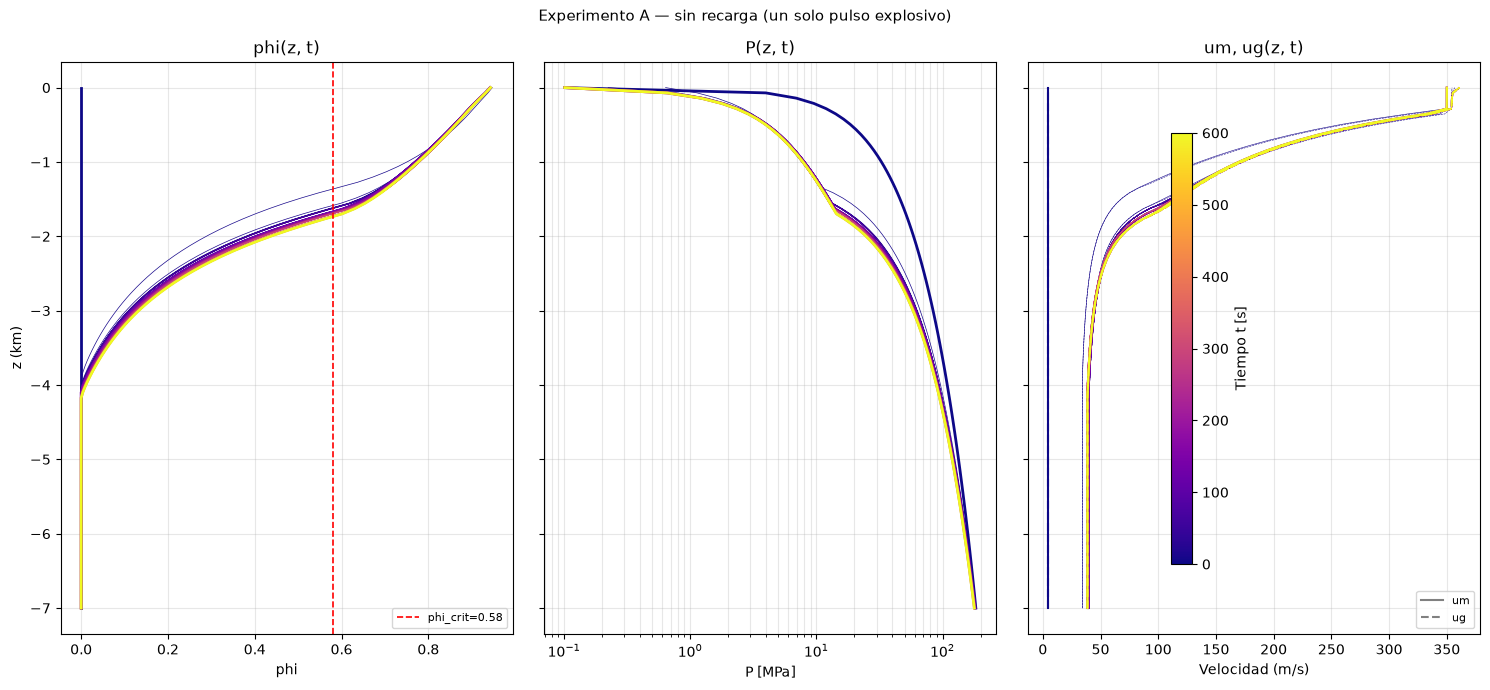

In [6]:
z_km  = outA['z'] / 1e3
cmap  = cm.plasma
normA = plt.Normalize(vmin=tA.min(), vmax=tA.max())
smA   = cm.ScalarMappable(cmap=cmap, norm=normA)
smA.set_array([])

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig2.suptitle('Experimento A — sin recarga (un solo pulso explosivo)', fontsize=11)

# phi(z, t)
ax = axes2[0]
for i, t in enumerate(tA):
    lw = 2.0 if i in [0, len(tA)//4, len(tA)//2, len(tA)-1] else 0.5
    ax.plot(outA['phi_hist'][i], z_km, color=cmap(normA(t)), lw=lw)
ax.axvline(outA['phicrit'], color='red', ls='--', lw=1.2, label=f"phi_crit={outA['phicrit']:.2f}")
ax.set_xlabel('phi')
ax.set_ylabel('z (km)')
ax.set_title('phi(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# P(z, t)
ax = axes2[1]
for i, t in enumerate(tA):
    lw = 2.0 if i in [0, len(tA)//4, len(tA)//2, len(tA)-1] else 0.5
    ax.semilogx(outA['P_hist'][i]/1e6, z_km, color=cmap(normA(t)), lw=lw)
ax.set_xlabel('P [MPa]')
ax.set_title('P(z, t)')
ax.grid(True, alpha=0.3, which='both')

# velocidades
ax = axes2[2]
for i, t in enumerate(tA):
    lw = 1.5 if i in [0, len(tA)//4, len(tA)//2, len(tA)-1] else 0.4
    c = cmap(normA(t))
    ax.plot(outA['um_hist'][i], z_km, color=c, lw=lw)
    ax.plot(outA['ug_hist'][i], z_km, color=c, lw=lw, ls='--')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='gray', lw=1.5, label='um'),
    Line2D([0],[0], color='gray', lw=1.5, ls='--', label='ug'),
], fontsize=8)
ax.set_xlabel('Velocidad (m/s)')
ax.set_title('um, ug(z, t)')
ax.grid(True, alpha=0.3)

fig2.colorbar(smA, ax=axes2.ravel().tolist(), shrink=0.8, pad=0.02, label='Tiempo t [s]')
plt.tight_layout()
plt.savefig('perfiles_phi_sin_recarga.png', dpi=150, bbox_inches='tight')
plt.show()

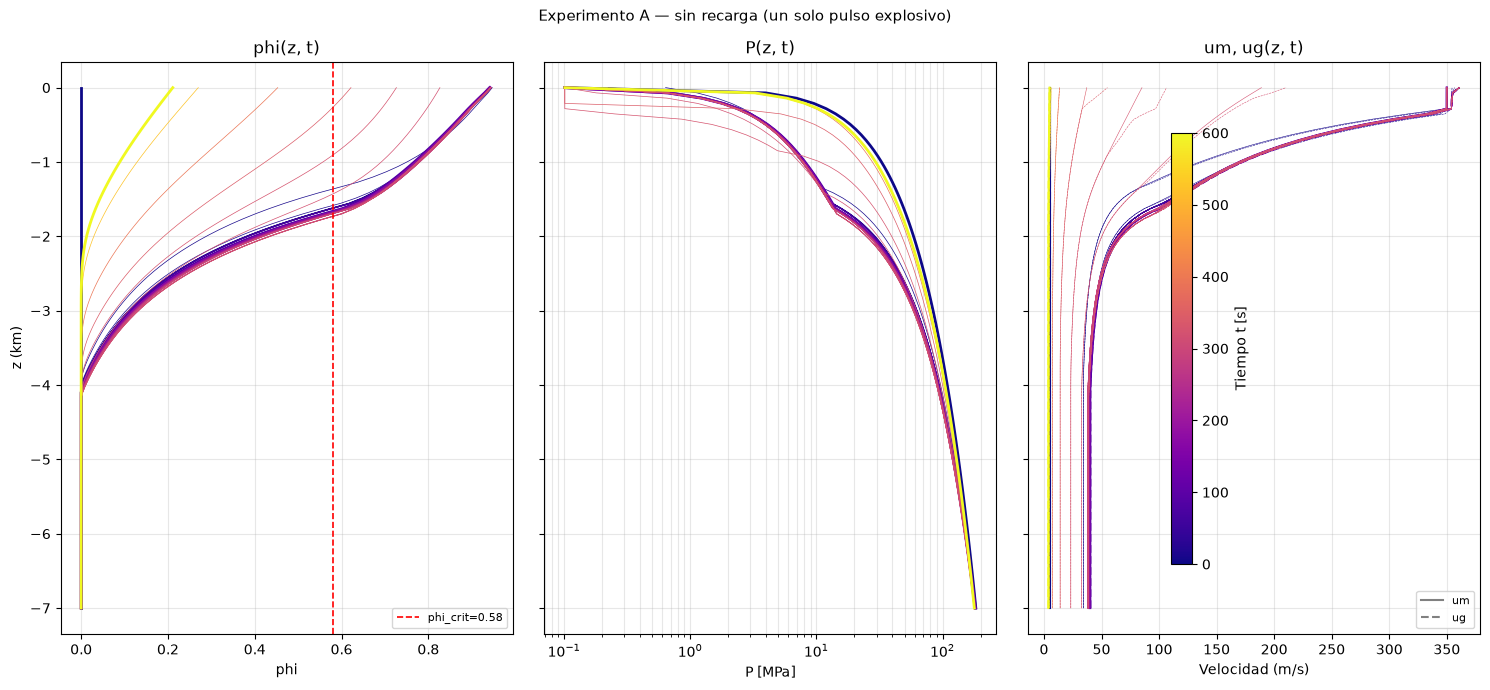

In [6]:
z_km  = outA['z'] / 1e3
cmap  = cm.plasma
normA = plt.Normalize(vmin=tA.min(), vmax=tA.max())
smA   = cm.ScalarMappable(cmap=cmap, norm=normA)
smA.set_array([])

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig2.suptitle('Experimento A — sin recarga (un solo pulso explosivo)', fontsize=11)

# phi(z, t)
ax = axes2[0]
for i, t in enumerate(tA):
    lw = 2.0 if i in [0, len(tA)//4, len(tA)//2, len(tA)-1] else 0.5
    ax.plot(outA['phi_hist'][i], z_km, color=cmap(normA(t)), lw=lw)
ax.axvline(outA['phicrit'], color='red', ls='--', lw=1.2, label=f"phi_crit={outA['phicrit']:.2f}")
ax.set_xlabel('phi')
ax.set_ylabel('z (km)')
ax.set_title('phi(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# P(z, t)
ax = axes2[1]
for i, t in enumerate(tA):
    lw = 2.0 if i in [0, len(tA)//4, len(tA)//2, len(tA)-1] else 0.5
    ax.semilogx(outA['P_hist'][i]/1e6, z_km, color=cmap(normA(t)), lw=lw)
ax.set_xlabel('P [MPa]')
ax.set_title('P(z, t)')
ax.grid(True, alpha=0.3, which='both')

# velocidades
ax = axes2[2]
for i, t in enumerate(tA):
    lw = 1.5 if i in [0, len(tA)//4, len(tA)//2, len(tA)-1] else 0.4
    c = cmap(normA(t))
    ax.plot(outA['um_hist'][i], z_km, color=c, lw=lw)
    ax.plot(outA['ug_hist'][i], z_km, color=c, lw=lw, ls='--')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='gray', lw=1.5, label='um'),
    Line2D([0],[0], color='gray', lw=1.5, ls='--', label='ug'),
], fontsize=8)
ax.set_xlabel('Velocidad (m/s)')
ax.set_title('um, ug(z, t)')
ax.grid(True, alpha=0.3)

fig2.colorbar(smA, ax=axes2.ravel().tolist(), shrink=0.8, pad=0.02, label='Tiempo t [s]')
plt.tight_layout()
plt.savefig('perfiles_phi_sin_recarga.png', dpi=150, bbox_inches='tight')
plt.show()

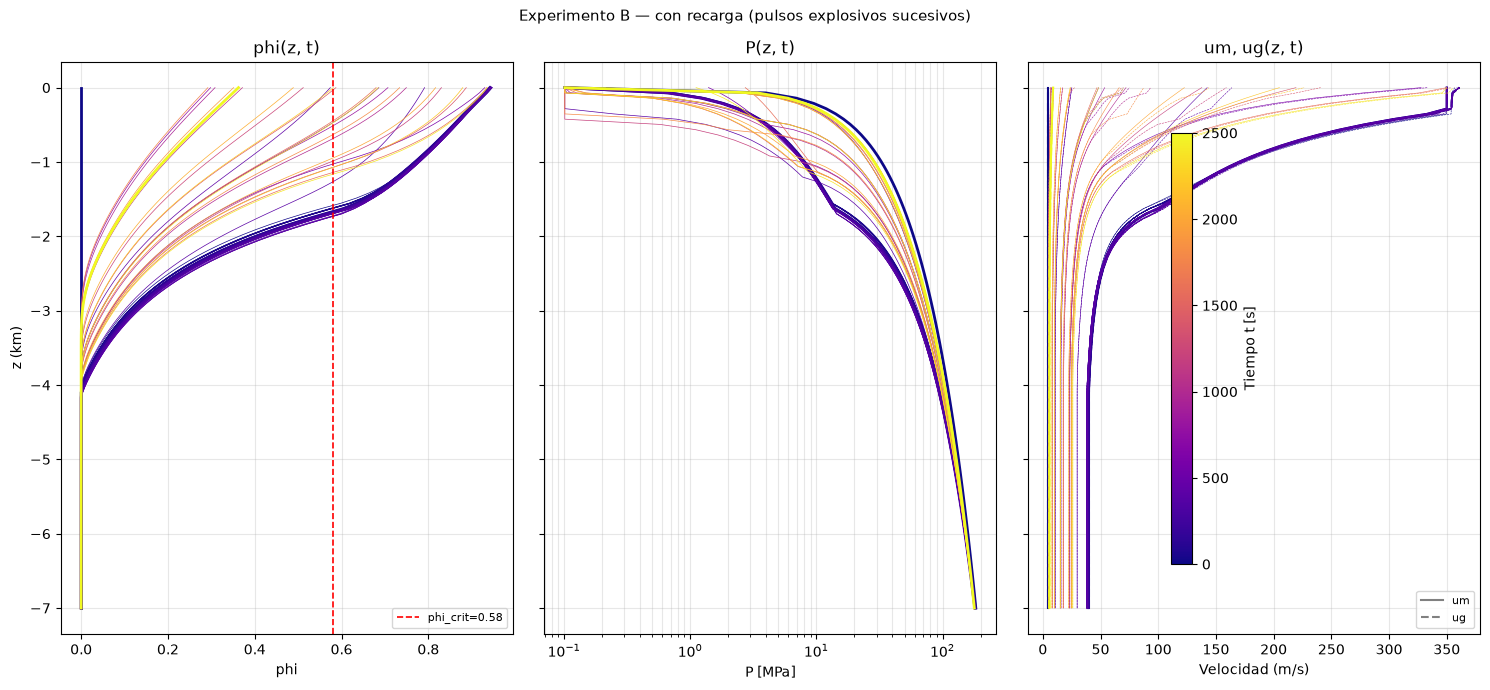

In [8]:
z_km  = outB['z'] / 1e3
cmap  = cm.plasma
normB = plt.Normalize(vmin=tB.min(), vmax=tB.max())
smB   = cm.ScalarMappable(cmap=cmap, norm=normB)
smB.set_array([])

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig2.suptitle('Experimento B — con recarga (pulsos explosivos sucesivos)', fontsize=11)

# phi(z, t)
ax = axes2[0]
for i, t in enumerate(tB):
    lw = 2.0 if i in [0, len(tB)//4, len(tB)//2, len(tB)-1] else 0.5
    ax.plot(outB['phi_hist'][i], z_km, color=cmap(normB(t)), lw=lw)
ax.axvline(outB['phicrit'], color='red', ls='--', lw=1.2, label=f"phi_crit={outB['phicrit']:.2f}")
ax.set_xlabel('phi')
ax.set_ylabel('z (km)')
ax.set_title('phi(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# P(z, t)
ax = axes2[1]
for i, t in enumerate(tB):
    lw = 2.0 if i in [0, len(tB)//4, len(tB)//2, len(tB)-1] else 0.5
    ax.semilogx(outB['P_hist'][i]/1e6, z_km, color=cmap(normB(t)), lw=lw)
ax.set_xlabel('P [MPa]')
ax.set_title('P(z, t)')
ax.grid(True, alpha=0.3, which='both')

# velocidades
ax = axes2[2]
for i, t in enumerate(tB):
    lw = 1.5 if i in [0, len(tB)//4, len(tB)//2, len(tB)-1] else 0.4
    c = cmap(normB(t))
    ax.plot(outB['um_hist'][i], z_km, color=c, lw=lw)
    ax.plot(outB['ug_hist'][i], z_km, color=c, lw=lw, ls='--')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='gray', lw=1.5, label='um'),
    Line2D([0],[0], color='gray', lw=1.5, ls='--', label='ug'),
], fontsize=8)
ax.set_xlabel('Velocidad (m/s)')
ax.set_title('um, ug(z, t)')
ax.grid(True, alpha=0.3)

fig2.colorbar(smB, ax=axes2.ravel().tolist(), shrink=0.8, pad=0.02, label='Tiempo t [s]')
plt.tight_layout()
plt.savefig('perfiles_phi_con_recarga.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Profundidad de fragmentación z_frag(t)

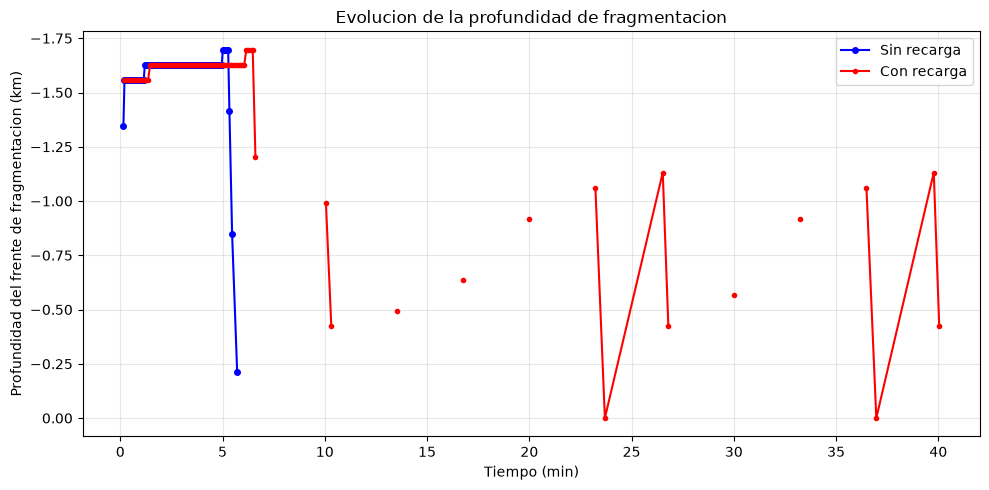

In [7]:
def get_z_frag(out):
    """Profundidad del frente de fragmentación para cada tiempo guardado."""
    z_frag = []
    for phi in out['phi_hist']:
        idx = np.where(phi >= out['phicrit'])[0]
        z_frag.append(out['z'][idx[0]] / 1e3 if len(idx) > 0 else np.nan)
    return np.array(z_frag)

zfA = get_z_frag(outA)
zfB = get_z_frag(outB)

fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(tA/60, zfA, 'b-o', ms=4, label='Sin recarga')
ax3.plot(tB/60, zfB, 'r-o', ms=3, label='Con recarga')
ax3.set_xlabel('Tiempo (min)')
ax3.set_ylabel('Profundidad del frente de fragmentacion (km)')
ax3.set_title('Evolucion de la profundidad de fragmentacion')
ax3.invert_yaxis()
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('z_frag_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumen comparativo

In [10]:
A_A = outA['A_conduit']
A_B = outB['A_conduit']

# Volumen total eruptado (masa)
from numpy import trapezoid
M_A = trapezoid(outA['q_hist'] * A_A, outA['t_save'])   # kg
M_B = trapezoid(outB['q_hist'] * A_B, outB['t_save'])   # kg

rho_m_est = 2463   # kg/m³ (del modelo)
V_A = M_A / rho_m_est / 1e9   # km³ DRE
V_B = M_B / rho_m_est / 1e9

print('Resumen:')
print(f'  Exp A (sin recarga):')
print(f'    Duracion fase explosiva: ~{tA[np.argmax(QA <= QA[1]*0.1)]/60:.1f} min')
print(f'    Q pico                 : {QA.max()/1e6:.2f} × 10^6 kg/s')
print(f'    Masa total eruptada    : {M_A/1e12:.3f} × 10^12 kg')
print(f'    Volumen DRE            : {V_A:.4f} km³')
print()
print(f'  Exp B (con recarga):')
print(f'    Q pico                 : {QB.max()/1e6:.2f} × 10^6 kg/s')
print(f'    Masa total eruptada    : {M_B/1e12:.3f} × 10^12 kg')
print(f'    Volumen DRE            : {V_B:.4f} km³')
print()
print('Calbuco 2015 (referencia observada):')
print('    Volumen DRE total      : ~0.27 km³')
print('    Q pico estimado        : ~1-5 × 10^6 kg/s')

Resumen:
  Exp A (sin recarga):
    Duracion fase explosiva: ~0.0 min
    Q pico                 : 80.02 × 10^6 kg/s
    Masa total eruptada    : 0.046 × 10^12 kg
    Volumen DRE            : 0.0187 km³

  Exp B (con recarga):
    Q pico                 : 80.03 × 10^6 kg/s
    Masa total eruptada    : 0.192 × 10^12 kg
    Volumen DRE            : 0.0778 km³

Calbuco 2015 (referencia observada):
    Volumen DRE total      : ~0.27 km³
    Q pico estimado        : ~1-5 × 10^6 kg/s
